In [1]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


# Model Structure
I used the Pretrained Transformer Encoder-only Distilroberta model for Sentiment Classification. When working with a small and class-imbalanced training dataset, selecting a pretrained Transformer Encoder fine-tuned with a classification head remains the optimal strategy. Pretraining on vast unlabeled text corpora equips the model with rich, general-purpose linguistic features prior to fine-tuning, which directly mitigates data scarcity.
The structure of the model (distilroberta-base) has 6 encoder blocks distilled on 12 layers and it has a hidden size of 768 dimensions and 82 million parameter. Each encloder block has a split of the hidden dimension and is connected by feet forward network and normalization.

# How did you handle the small and imbalanced training set?
When working with a small and class-imbalanced training dataset, I used class weights balancing to penalise errors on minority data. I also used k-folds to measure the validation accuracy on balanced data. Pretraining on vast unlabeled text corpora equips the model with rich, general-purpose linguistic features prior to fine-tuning, which directly mitigates data scarcity.

# key training techniques (such as the choice of learning rate, optimizer, batch size):
Below cell (first approach) uses the Distilroberta model on whole training set which acheived ~ 69% accuracy on test data and it was overfitting for the positive sample. With further analysis I used Distilroberta model along with K-fold validation (second appoarch) to avoid overfitting to achieving higher accuracy. Initially I used the batch size as 16 which was exhausting the available ram in my cpu, hence reduced the batch size to 4 and modified the learning rate from 2e-5 to 1e-5 to match the batch size reduced and achieved higher accuracy of ~ 78% with less overfitting and better generalization.
Optimizer: I chose AdamW optimizer because our training set is small (only 240 samples), and achieving strong regularization is critical to prevent the model from memorizing individual reviews. Hence decoupled weight decay which ensures consistent regularization across all parameters regardless of gradient magnitudes.

# evaluation result in total accuracy, and a confusion matrix on the given public test data samples.
1st approach --> 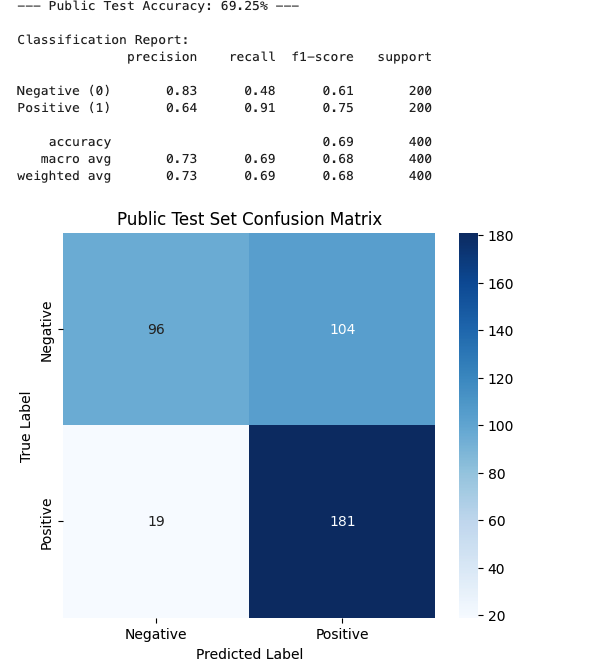

2nd approach --> 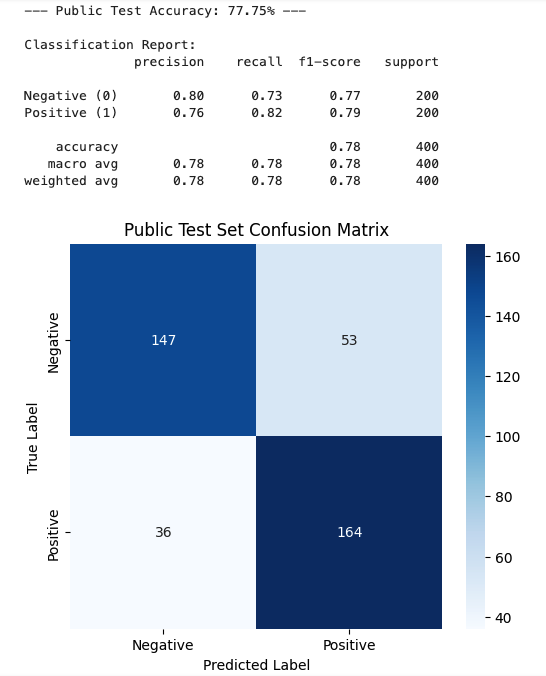

# If you use online references, acknowledge them in your writeup. If you use generative AI tools, specifically include an 'Use of AI' section.
I used the following reference:
1) Lecture notes
2) github code from Lecture notes
3) Gemini - AI agent
4) Claude - AI agent

Using device: mps
Train Shape: (240, 5)
Public Test Shape: (400, 5)

Train Label Distribution:
label
1    180
0     60
Name: count, dtype: int64
Calculated Class Weights (Negative [0], Positive [1]): [2.        0.6666667]


Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:00<00:00, 6565.18it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were

Epoch 1/5 - Loss: 0.6981
Epoch 2/5 - Loss: 0.6849
Epoch 3/5 - Loss: 0.6822
Epoch 4/5 - Loss: 0.6219
Epoch 5/5 - Loss: 0.4739


Writing model shards: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.31it/s]



Model and tokenizer saved successfully to 'model_checkpoint/'

--- Public Test Accuracy: 69.25% ---

Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.83      0.48      0.61       200
Positive (1)       0.64      0.91      0.75       200

    accuracy                           0.69       400
   macro avg       0.73      0.69      0.68       400
weighted avg       0.73      0.69      0.68       400



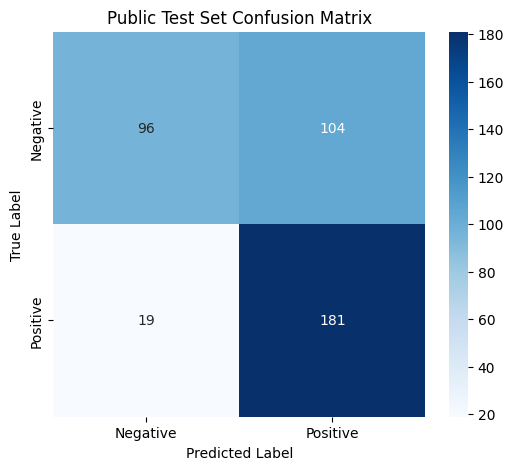

Saved predictions to 'public_test_predictions.csv'


In [4]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW # Corrected import
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Using device: {device}")

# ## Data Loading & Preprocessing

# %%
train_df = pd.read_csv("train.csv")
public_test_df = pd.read_csv("public_test.csv")

print(f"Train Shape: {train_df.shape}")
print(f"Public Test Shape: {public_test_df.shape}")
print("\nTrain Label Distribution:")
print(train_df['label'].value_counts())

# MODEL_NAME = "roberta-base"
MODEL_NAME = "distilroberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class MovieReviewDataset(Dataset):
    def __init__(self, texts, labels=None, max_len=256):
        self.texts = texts
        self.labels = labels
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        item = {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten()
        }
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = MovieReviewDataset(train_df['text'].values, train_df['label'].values)
test_dataset = MovieReviewDataset(public_test_df['text'].values, public_test_df['label'].values)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)


# ## Class Weight Calculation & Loss Definition

# %%
# Compute inverse class weights to handle 180:60 imbalance
classes = np.unique(train_df['label'].values)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=train_df['label'].values)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print(f"Calculated Class Weights (Negative [0], Positive [1]): {class_weights_tensor.cpu().numpy()}")

loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

# ## Model Initialization & Fine-Tuning

# %%
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(device)

EPOCHS = 5
optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

model.train()
for epoch in range(EPOCHS):
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f}")

# Save Stage 1 Checkpoint
SAVE_DIR = "model_checkpoint"
os.makedirs(SAVE_DIR, exist_ok=True)
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"\nModel and tokenizer saved successfully to '{SAVE_DIR}/'")

# ## Evaluation on Public Test Set

# %%
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Evaluation Metrics
accuracy = accuracy_score(all_labels, all_preds)
print(f"\n--- Public Test Accuracy: {accuracy * 100:.2f}% ---\n")
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=["Negative (0)", "Positive (1)"]))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Public Test Set Confusion Matrix")
plt.show()

# ## Save Predictions CSV

# %%
output_df = pd.DataFrame({
    'id': public_test_df['id'],
    'predicted_label': all_preds
})

output_df.to_csv("public_test_predictions.csv", index=False)
print("Saved predictions to 'public_test_predictions.csv'")

Using device: mps
Train Shape: (240, 5)
Public Test Shape: (400, 5)

Train Label Distribution:
label
1    180
0     60
Name: count, dtype: int64
Calculated Class Weights (Negative [0], Positive [1]): [2.        0.6666667]
Starting 5-Fold Cross-Validation with Early Stopping...

--- Fold 1 ---


Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:00<00:00, 7811.92it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were

Epoch 1: Val Loss: 0.6825 | Val Acc: 0.7500
Epoch 2: Val Loss: 0.6956 | Val Acc: 0.7500
Epoch 3: Val Loss: 0.6652 | Val Acc: 0.7708
Epoch 4: Val Loss: 0.6406 | Val Acc: 0.7500
Epoch 5: Val Loss: 0.3887 | Val Acc: 0.7708
Epoch 6: Val Loss: 0.6616 | Val Acc: 0.6875
Epoch 7: Val Loss: 0.8216 | Val Acc: 0.7708
Early stopping triggered.

--- Fold 2 ---


Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:00<00:00, 4807.69it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were

Epoch 1: Val Loss: 0.6865 | Val Acc: 0.7500
Epoch 2: Val Loss: 0.6856 | Val Acc: 0.7500
Epoch 3: Val Loss: 0.6874 | Val Acc: 0.7500
Epoch 4: Val Loss: 0.6692 | Val Acc: 0.7500
Epoch 5: Val Loss: 0.6843 | Val Acc: 0.7292
Epoch 6: Val Loss: 1.7548 | Val Acc: 0.7500
Early stopping triggered.

--- Fold 3 ---


...

Epoch 1: Val Loss: 0.6773 | Val Acc: 0.7500
Epoch 2: Val Loss: 0.6740 | Val Acc: 0.7500
Epoch 3: Val Loss: 0.6762 | Val Acc: 0.7500
Epoch 4: Val Loss: 0.6292 | Val Acc: 0.7500
Epoch 5: Val Loss: 0.6357 | Val Acc: 0.7708
Epoch 6: Val Loss: 0.4556 | Val Acc: 0.8542
Epoch 7: Val Loss: 0.8806 | Val Acc: 0.8125
Epoch 8: Val Loss: 0.9624 | Val Acc: 0.8333
Early stopping triggered.

--- Fold 5 ---


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:00<00:00, 7267.66it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were n

Epoch 1: Val Loss: 0.6744 | Val Acc: 0.7500
Epoch 2: Val Loss: 0.6693 | Val Acc: 0.7500
Epoch 3: Val Loss: 0.6605 | Val Acc: 0.7500
Epoch 4: Val Loss: 0.6571 | Val Acc: 0.5625
Epoch 5: Val Loss: 0.5691 | Val Acc: 0.6875
Epoch 6: Val Loss: 0.5660 | Val Acc: 0.6875
Epoch 7: Val Loss: 0.7714 | Val Acc: 0.7292
Epoch 8: Val Loss: 0.7443 | Val Acc: 0.7708
Early stopping triggered.

Cross-validation complete. Avg Val Loss: 0.5421


Writing model shards: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.80s/it]



Model and tokenizer saved successfully to 'model_checkpoint/'

--- Public Test Accuracy: 77.75% ---

Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.80      0.73      0.77       200
Positive (1)       0.76      0.82      0.79       200

    accuracy                           0.78       400
   macro avg       0.78      0.78      0.78       400
weighted avg       0.78      0.78      0.78       400



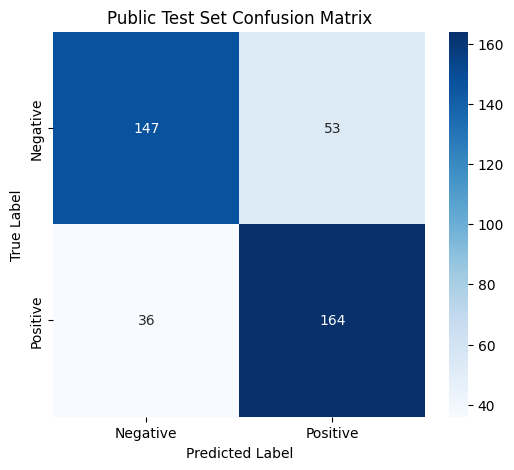

Saved predictions to 'public_test_predictions.csv'


In [5]:
from sklearn.model_selection import StratifiedKFold
import copy
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW # Corrected import
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Using device: {device}")

# ## Data Loading & Preprocessing

# %%
train_df = pd.read_csv("train.csv")
public_test_df = pd.read_csv("public_test.csv")

print(f"Train Shape: {train_df.shape}")
print(f"Public Test Shape: {public_test_df.shape}")
print("\nTrain Label Distribution:")
print(train_df['label'].value_counts())

# MODEL_NAME = "roberta-base"
MODEL_NAME = "distilroberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class MovieReviewDataset(Dataset):
    def __init__(self, texts, labels=None, max_len=256):
        self.texts = texts
        self.labels = labels
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        item = {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten()
        }
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = MovieReviewDataset(train_df['text'].values, train_df['label'].values)
test_dataset = MovieReviewDataset(public_test_df['text'].values, public_test_df['label'].values)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)


# ## Class Weight Calculation & Loss Definition

# %%
# Compute inverse class weights to handle 180:60 imbalance
classes = np.unique(train_df['label'].values)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=train_df['label'].values)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print(f"Calculated Class Weights (Negative [0], Positive [1]): {class_weights_tensor.cpu().numpy()}")

loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Configuration for K-Fold and Early Stopping
N_SPLITS = 5
SKF = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=3)
PATIENCE = 2

texts = train_df['text'].values
labels = train_df['label'].values

fold_results = []

print(f"Starting {N_SPLITS}-Fold Cross-Validation with Early Stopping...")

for fold, (train_idx, val_idx) in enumerate(SKF.split(texts, labels)):
    print(f"\n--- Fold {fold + 1} ---")

    # Prepare fold datasets
    train_sub = MovieReviewDataset(texts[train_idx], labels[train_idx])
    val_sub = MovieReviewDataset(texts[val_idx], labels[val_idx])

    train_loader_fold = DataLoader(train_sub, batch_size=4, shuffle=True)
    val_loader_fold = DataLoader(val_sub, batch_size=4, shuffle=False)

    # Initialize fresh model and optimizer for each fold
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)
    optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)

    best_val_loss = float('inf')
    early_stop_counter = 0
    best_model_state = None

    for epoch in range(10): # Max epochs, to be limited by early stopping
        model.train()
        train_loss = 0
        for batch in train_loader_fold:
            optimizer.zero_grad()
            ids, mask, targets = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)
            outputs = model(ids, attention_mask=mask)
            # Using standard CrossEntropyLoss with weights defined earlier
            loss = loss_fn(outputs.logits, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        val_preds, val_targets = [], []
        with torch.no_grad():
            for batch in val_loader_fold:
                ids, mask, targets = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)
                outputs = model(ids, attention_mask=mask)
                loss = loss_fn(outputs.logits, targets)
                val_loss += loss.item()
                val_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
                val_targets.extend(targets.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader_fold)
        val_acc = accuracy_score(val_targets, val_preds)

        print(f"Epoch {epoch+1}: Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")

        # Early Stopping Logic
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            early_stop_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            early_stop_counter += 1
            if early_stop_counter >= PATIENCE:
                print("Early stopping triggered.")
                break

    fold_results.append(best_val_loss)

print(f"\nCross-validation complete. Avg Val Loss: {np.mean(fold_results):.4f}")
# Save Stage 1 Checkpoint
SAVE_DIR = "model_checkpoint"
os.makedirs(SAVE_DIR, exist_ok=True)
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"\nModel and tokenizer saved successfully to '{SAVE_DIR}/'")

# ## Evaluation on Public Test Set

# %%
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Evaluation Metrics
accuracy = accuracy_score(all_labels, all_preds)
print(f"\n--- Public Test Accuracy: {accuracy * 100:.2f}% ---\n")
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=["Negative (0)", "Positive (1)"]))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Public Test Set Confusion Matrix")
plt.show()

# ## Save Predictions CSV

# %%
output_df = pd.DataFrame({
    'id': public_test_df['id'],
    'predicted_label': all_preds
})

output_df.to_csv("public_test_predictions.csv", index=False)
print("Saved predictions to 'public_test_predictions.csv'")